# EDA FHS

Notebook: análise descritiva e exploratória do dataset FHS. Execute todas as células para gerar os artefatos em `../eda_reports/` (subpastas: `csv`, `images`, `pdf`).

In [1]:
# Configura caminhos e imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from fpdf import FPDF

# Global output settings
OUTPUT_DPI = 800  # change this value to control DPI for all saved images
PDF_FILENAME = 'EDA_FHS_report.v1.pdf'
DUPLICATE_ROWS = None
LINHAS_INICIAIS = None
COLUNAS_INICIAIS = None
BASE = os.path.join('..','')
RAW = os.path.join('..','data','raw')
IMAGES = os.path.join('..','eda_reports','images')
CSV_DIR = os.path.join('..','eda_reports','csv')
PDF_DIR = os.path.join('..','eda_reports','pdf')
os.makedirs(IMAGES, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(PDF_DIR, exist_ok=True)
EXCLUDE_COLUMNS = ['__cls_tmp__', 'TenYearCHD', 'id','stroke', 'y', 'orig_index', 'stroke','id', 'ID', 'patient_id', 'pid', 'fold', 'y_train', 'prob_0', 'prob_1', 'y_proba', 'y_pred']
COLS_TO_REMOVE_LITERATURE = [] 
COLS_TO_REMOVE_MISSING = []
COLS_TO_INPUTATION = []
VARIAVEIS_CATEGORICAS = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

# Ajustes visuais
sns.set(style='whitegrid')

In [2]:
# Carrega dataset - ajusta automaticamente se houver um CSV em data/raw ou em eda_reports/csv
fn_raw = [f for f in os.listdir(RAW) if f.lower().endswith('.csv')]
if len(fn_raw) == 0:
    raise FileNotFoundError(f'Nenhum CSV encontrado em {RAW}. Coloque o fhs_framingham_user.csv em data/raw e reexecute.')
csv_path = os.path.join(RAW, fn_raw[0])  # corrigido: usar fn_raw em vez de fn
print('Carregando:', csv_path)
# Leitura defensiva: tenta inferir separador e encoding simples
try:
    df = pd.read_csv(csv_path, sep=';')
except Exception:
    # tenta com sep=';' como fallback
    df = pd.read_csv(csv_path, sep=',')

# Remover colunas identificadoras (ID) desde o início para que não apareçam em nenhuma análise
id_candidates = [c for c in df.columns if c.lower() in ('id','patient_id','patientid','record_id','serial_number')]

# df['hypertension'] = df['hypertension'].map({0:'No', 1:'Yes'})
# df['heart_disease'] = df['heart_disease'].map({0:'No', 1:'Yes'})
df.head()

Carregando: ../data/raw/fhs_framingham_user.csv


,id,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,2,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,3,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,4,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,5,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:

df.dropna(inplace=True)    
# df.describe(include='all')
df.isna().sum() 
# df['gender'].unique()
#4240 rows × 17 columns
#3658 rows × 17 columns

df  

,id,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,2,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,3,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,4,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,5,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,4234,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,4235,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4237,4238,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,4239,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [4]:
# =========================================
# Tipagem baseada SOMENTE no seu vetor VARIAVEIS_CATEGORICAS
# e exclusão total de EXCLUDE_COLUMNS das análises
# =========================================
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# --- parâmetros vindos do ambiente ---
EXCLUDE_COLUMNS = list(globals().get("EXCLUDE_COLUMNS", []))
VARIAVEIS_CATEGORICAS = list(globals().get("VARIAVEIS_CATEGORICAS", []))
CSV_DIR = str(globals().get("CSV_DIR", "."))

os.makedirs(CSV_DIR, exist_ok=True)

# --- DataFrame de trabalho (sem colunas excluídas) ---
df = df.copy()
df_work = df.drop(columns=EXCLUDE_COLUMNS, errors='ignore')

# ============================
# Colunas categóricas = exatamente as do seu vetor
# ============================
# Mantém apenas as que existem no df_work e preserva a ordem dada
cat_cols = [c for c in VARIAVEIS_CATEGORICAS if c in df_work.columns]

# Aviso de categorias ausentes (estavam no vetor mas não no dataframe após exclusão)
missing_cats = [c for c in VARIAVEIS_CATEGORICAS if c not in df_work.columns]
if missing_cats:
    print(f"[Aviso] As seguintes categorias do vetor não existem após exclusões: {missing_cats}")

# As demais colunas (após exclusões) serão tratadas como não-categóricas (numéricas/contínuas para estatística)
num_cols = [c for c in df_work.columns if c not in cat_cols]

# ============================
# Duplicidades (ignora EXCLUDE_COLUMNS pois já foram removidas)
# ============================
LINHAS_INICIAIS = df.shape[0]
COLUNAS_INICIAIS = df.shape[1]

cols_consider = df_work.columns.tolist()
if len(cols_consider) == 0:
    DUPLICATE_ROWS = df.duplicated(keep='first')
else:
    DUPLICATE_ROWS = df.duplicated(subset=cols_consider, keep='first')

if DUPLICATE_ROWS.sum() > 0:
    print(f'Encontradas {DUPLICATE_ROWS.sum()} linhas duplicadas. Gravando arquivo e removendo do dataset.')
    df.loc[DUPLICATE_ROWS].to_csv(os.path.join(CSV_DIR, 'DUPLICATE_ROWS.csv'), index=False)
    df = df.loc[~DUPLICATE_ROWS].copy()
    # atualiza df_work após remoção
    df_work = df.drop(columns=EXCLUDE_COLUMNS, errors='ignore')
    # re-sincroniza listas (caso alguma coluna tenha sido afetada por etapas anteriores)
    cat_cols = [c for c in cat_cols if c in df_work.columns]
    num_cols = [c for c in df_work.columns if c not in cat_cols]
    print('Novas dimensões após remoção de duplicados:', df.shape)

# ============================
# Remover possíveis identificadores das análises
# ============================
id_candidates = [c for c in df_work.columns
                 if c.lower() in ('id','stroke','patient_id','patientid','record_id','serial_number')]
if id_candidates:
    print('Removing identifier columns from analysis:', id_candidates)
    df_work = df_work.drop(columns=id_candidates, errors='ignore')
    cat_cols = [c for c in cat_cols if c not in id_candidates]
    num_cols = [c for c in num_cols if c not in id_candidates]

print('Numéricas/contínuas (não-categóricas):', len(num_cols))
print('Categóricas (do seu vetor):', len(cat_cols))
print('Excluídas da análise:', len(EXCLUDE_COLUMNS), '→', EXCLUDE_COLUMNS)

# ============================
# Estatísticas descritivas — numéricas/contínuas
# ============================
if len(num_cols) > 0:
    # Coerção segura a numérico apenas para cálculo (se alguma coluna não for numérica de fato)
    num_df = df_work[num_cols].apply(lambda x: pd.to_numeric(x, errors='coerce'))
    desc = num_df.describe().T
    try:
        desc['skewness'] = num_df.apply(lambda x: skew(x.dropna()) if x.dropna().shape[0] > 0 else np.nan)
        desc['kurtosis'] = num_df.apply(lambda x: kurtosis(x.dropna()) if x.dropna().shape[0] > 0 else np.nan)
    except Exception:
        pass
    try:
        display(desc)
    except Exception:
        print(desc)
else:
    print('Nenhuma coluna numérica/contínua para estatísticas descritivas.')

# ============================
# Frequências — categóricas (do vetor)
# ============================
if len(cat_cols) == 0:
    print('Nenhuma coluna categórica do vetor presente após exclusões.')
else:
    for c in cat_cols[:10]:
        try:
            print('---', c, '---')
            vc = df_work[c].value_counts(dropna=False).head(20)
            try:
                display(vc)
            except Exception:
                print(vc)
        except Exception as e:
            print('Falha ao mostrar frequências para', c, e)


Numéricas/contínuas (não-categóricas): 8
Categóricas (do seu vetor): 7
Excluídas da análise: 17 → ['__cls_tmp__', 'TenYearCHD', 'id', 'stroke', 'y', 'orig_index', 'stroke', 'id', 'ID', 'patient_id', 'pid', 'fold', 'y_train', 'prob_0', 'prob_1', 'y_proba', 'y_pred']


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,3658.0,49.551941,8.562029,32.00,42.00,49.00,56.0000,70.0,0.231911,-0.992193
cigsPerDay,3658.0,9.025424,11.921590,0.00,0.00,0.00,20.0000,70.0,1.228362,0.954456
totChol,3658.0,236.847731,44.097681,113.00,206.00,234.00,263.0000,600.0,0.664062,1.837163
sysBP,3658.0,132.370558,22.086866,83.50,117.00,128.00,143.8750,295.0,1.163134,2.273857
diaBP,3658.0,82.917031,11.974258,48.00,75.00,82.00,90.0000,142.5,0.709116,1.256307
BMI,3658.0,25.782802,4.065601,15.54,23.08,25.38,28.0375,56.8,0.999196,2.829948
heartRate,3658.0,75.730727,11.981525,44.00,68.00,75.00,82.0000,143.0,0.670563,1.059302
glucose,3658.0,81.852925,23.904164,40.00,71.00,78.00,87.0000,394.0,6.279334,60.045265


--- male ---


male
0    2035
1    1623
Name: count, dtype: int64

--- education ---


...

prevalentStroke
0    3637
1      21
Name: count, dtype: int64

--- prevalentHyp ---


prevalentHyp
0    2518
1    1140
Name: count, dtype: int64

--- diabetes ---


diabetes
0    3559
1      99
Name: count, dtype: int64

/tmp/ipykernel_58431/2845766713.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s_plot, order=order, ax=ax, palette=palette)
/tmp/ipykernel_58431/2845766713.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s_plot, order=order, ax=ax, palette=palette)
/tmp/ipykernel_58431/2845766713.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s_plot, order=order, ax=ax, palette=palette)
/tmp/ipykernel_58431/2845766713.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. A

Figura salva em: ../eda_reports/images/balance_categorical_selected.png


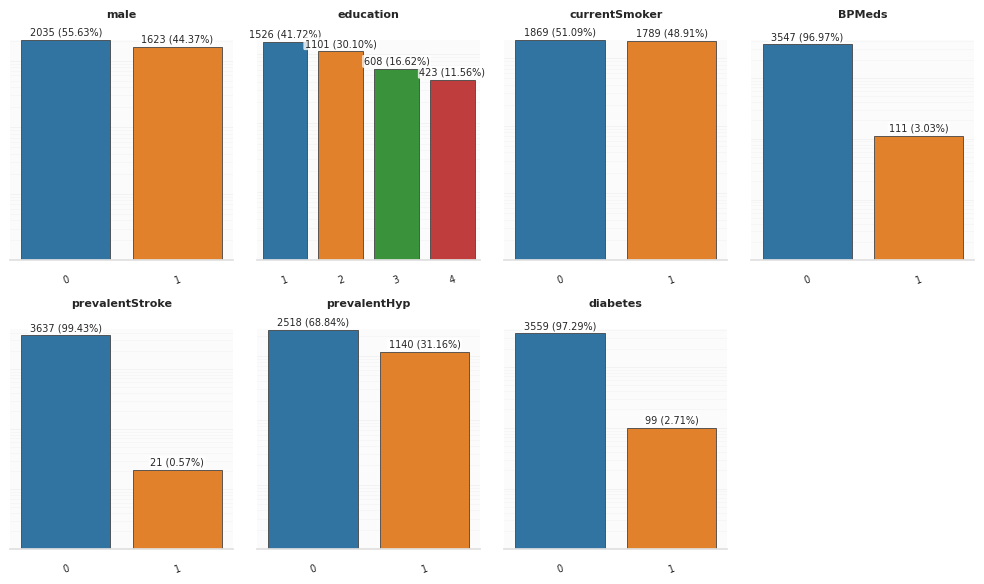

In [5]:
# Balanceamento das variáveis categóricas (corrigido: labels/ordem consistentes)
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, textwrap

VARIAVEIS_CATEGORICAS = ['male','education','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes']
EXCLUDE_COLUMNS = list(globals().get('EXCLUDE_COLUMNS', []))
assert 'df' in globals(), "Defina o DataFrame principal em `df`."

sns.set_theme(style='whitegrid', rc={'axes.edgecolor':'#E0E0E0','grid.color':'#DADADA','grid.linewidth':0.6,'axes.labelsize':8,'font.size':8})

VARS = [c for c in VARIAVEIS_CATEGORICAS if (c in df.columns) and (c not in EXCLUDE_COLUMNS)]
if not VARS:
    print("Nenhuma das variáveis solicitadas está no DataFrame (ou foram todas excluídas).")
else:
    PALETTE_BINARY = ['#1f77b4', '#ff7f0e']
    DEFAULT_MULTI = 'tab10'

    def norm_generic(s: pd.Series):
        if pd.api.types.is_numeric_dtype(s):
            return s
        s = s.astype(str).str.strip()
        s = s.replace({
            '': np.nan, 'nan': np.nan, 'NaN': np.nan, 'None': np.nan, 'NONE': np.nan,
            '-': np.nan, '—': np.nan, '–': np.nan
        })
        return s

    def norm_binary_01(s: pd.Series):
        if pd.api.types.is_numeric_dtype(s):
            return pd.to_numeric(s, errors='coerce').round().clip(0,1)
        s = s.astype(str).str.strip().str.lower()
        s = s.replace({'': np.nan, 'nan': np.nan, 'none': np.nan, '-': np.nan, '—': np.nan, '–': np.nan})
        s = s.replace({'true':1,'t':1,'1':1,'yes':1,'y':1,'sim':1,
                       'false':0,'f':0,'0':0,'no':0,'n':0,'nao':0,'não':0})
        return pd.to_numeric(s, errors='coerce')

    NORMALIZERS = {
        'male': norm_binary_01,
        'currentSmoker': norm_binary_01,
        'BPMeds': norm_binary_01,
        'prevalentStroke': norm_binary_01,
        'prevalentHyp': norm_binary_01,
        'diabetes': norm_binary_01,
        'education': norm_generic,  # 1..4 (numérica discreta)
    }

    # helper: cria série de rótulos para plot e a ordem, de forma CONSISTENTE
    def make_plot_labels(s: pd.Series, colname: str):
        s_norm = NORMALIZERS.get(colname, norm_generic)(s.copy())

        # Se binária/inteira, formatar como inteiros sem ".0"
        is_numeric = pd.api.types.is_numeric_dtype(s_norm)
        if is_numeric:
            # tentar converter para inteiro preservando NaN
            try:
                s_int = pd.to_numeric(s_norm, errors='coerce').round()
                # se todas são quase-inteiras, usa rótulo inteiro
                if s_int.dropna().eq(s_norm.dropna()).all() or colname in {'male','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes','education'}:
                    s_plot = s_int.astype('Int64').astype(str)
                else:
                    # números realmente não-inteiros: usar formatação padrão
                    s_plot = s_norm.astype(str)
            except Exception:
                s_plot = s_norm.astype(str)
        else:
            s_plot = s_norm.astype(str)

        # construir ordem a partir da MESMA série usada no plot
        counts = s_plot.value_counts(dropna=True)
        order = counts.index.tolist()
        return s_plot, order, counts

    cols = 4
    rows = (len(VARS) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(10, 6), constrained_layout=False)
    fig.patch.set_facecolor('white')
    axes = np.atleast_1d(axes).flatten()

    for i, c in enumerate(VARS):
        ax = axes[i]
        ax.set_facecolor('#fbfbfb')

        s_plot, order, counts = make_plot_labels(df[c], c)
        n_cat = len(order)

        if n_cat <= 1:
            ax.set_title(textwrap.fill(c, 30), fontsize=8, fontweight='bold', pad=16)
            ax.text(0.5, 0.5, 'Categoria única ou vazia', ha='center', va='center', fontsize=7)
            ax.axis('off')
            continue

        # Paleta
        # binária: tente detectar {0,1} como strings
        if n_cat == 2 and set(order) == {'0','1'}:
            palette = PALETTE_BINARY
        else:
            palette = sns.color_palette(DEFAULT_MULTI, n_cat)

        sns.countplot(x=s_plot, order=order, ax=ax, palette=palette)

        ax.set_title(textwrap.fill(str(c), 30), fontsize=8, fontweight='bold', pad=16)
        ax.set_xlabel(''); ax.set_ylabel('')
        ax.tick_params(axis='y', which='both', labelleft=False)
        ax.tick_params(axis='x', labelsize=7, rotation=20)
        ax.set_yscale('log')

        denom = s_plot.replace({'<NA>': np.nan}).notna().sum()
        for p in ax.patches:
            try:
                p.set_linewidth(0.6); p.set_edgecolor('#444444')
            except Exception:
                pass
            h = p.get_height()
            if h and h > 0 and denom > 0:
                pct = h / denom * 100.0
                ax.annotate(f'{int(h)} ({pct:.2f}%)',
                            (p.get_x() + p.get_width() / 2., h),
                            ha='center', va='bottom', fontsize=7,
                            xytext=(0, 2), textcoords='offset points',
                            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.8))

        ax.grid(axis='y', which='major', linestyle='-', alpha=0.3)
        ax.grid(axis='y', which='minor', linestyle='-', alpha=0.15)
        ax.set_ylim(bottom=1)
        sns.despine(ax=ax, left=True, right=True, top=True, bottom=False)

    # remove eixos extras
    last_i = len(VARS) - 1
    for j in range(last_i + 1, len(axes)):
        fig.delaxes(axes[j])

    # salvar figura
    try:
        try:
            IMAGES
        except NameError:
            IMAGES = os.path.join(BASE, 'eda_reports', 'images') if 'BASE' in globals() else os.path.join('eda_reports','images')
        os.makedirs(IMAGES, exist_ok=True)
        dpi = OUTPUT_DPI if 'OUTPUT_DPI' in globals() else 300
        out_path = os.path.join(IMAGES, 'balance_categorical_selected.png')
        plt.tight_layout(pad=1.6, w_pad=0.8, h_pad=1.2)
        plt.savefig(out_path, dpi=dpi, bbox_inches='tight')
        print(f'Figura salva em: {out_path}')
    except Exception as e:
        print('Falha ao salvar figura:', e)

    plt.show()


In [6]:
# === VIF (todas as variáveis exceto EXCLUDE_COLUMNS) =======================
# - Respeita EXCLUDE_COLUMNS
# - Remove alvo/IDs (ex.: TARGET_COLUMN, TenYearCHD, id-like)
# - Binários texto ('t','f','true','false','0','1','yes','no','sim','nao/ não') -> 0/1
# - Categóricas não-binárias -> one-hot (drop_first=True)
# - Salva em CSV_DIR/vif_values.csv
# ===========================================================================

import os
import numpy as np
import pandas as pd

# --- Pré-requisitos ---
assert 'df' in globals(), "Defina seu DataFrame principal em `df` antes de rodar esta célula."

CSV_DIR = str(globals().get('CSV_DIR', './csv'))
os.makedirs(CSV_DIR, exist_ok=True)

EXCLUDE_COLUMNS = list(globals().get('EXCLUDE_COLUMNS', []))
TARGET_COLUMN   = globals().get('TARGET_COLUMN', 'TenYearCHD')  # ajuste se necessário

# --------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------
BIN_TRUE  = {'t','true','1','yes','y','sim'}
BIN_FALSE = {'f','false','0','no','n','nao','não'}

def _clean_text(s: pd.Series) -> pd.Series:
    """Limpa strings comuns de vazio e normaliza para minúsculas."""
    s = s.astype(str).str.strip().str.lower()
    s = s.replace({'': np.nan, 'nan': np.nan, 'none': np.nan, '-': np.nan, '—': np.nan, '–': np.nan})
    return s

def _maybe_to_numeric(series: pd.Series) -> pd.Series:
    """Tenta converter strings numéricas para números se boa parte for convertível."""
    coerced = pd.to_numeric(series, errors='coerce')
    if coerced.notna().sum() >= 0.5 * len(series):
        return coerced
    return series

def _encode_binary_tf(series: pd.Series) -> pd.Series:
    """
    Se a coluna for texto binário (t/f, true/false, yes/no, 0/1, sim/não), mapeia para 0/1.
    Caso contrário, devolve a série original.
    """
    if series.dtype == object:
        s = _clean_text(series)
        uniq = set(s.dropna().unique())
        if len(uniq) > 0 and uniq.issubset(BIN_TRUE | BIN_FALSE):
            mapped = s.map(lambda v: 1 if v in BIN_TRUE else (0 if v in BIN_FALSE else np.nan))
            return pd.to_numeric(mapped, errors='coerce')
    return series

def _drop_id_target_cols(df_in: pd.DataFrame) -> pd.DataFrame:
    """Remove colunas alvo e colunas com cara de ID."""
    df_out = df_in.copy()
    # alvo(s) usuais
    drop_candidates = set([TARGET_COLUMN, 'diagnosis', 'target', 'class', 'TenYearCHD']) & set(df_out.columns)
    if drop_candidates:
        df_out = df_out.drop(columns=list(drop_candidates))
    # IDs
    id_like = [c for c in df_out.columns if ('id' in c.lower()) or (c.lower() in {'patient_id','record_id'})]
    if id_like:
        df_out = df_out.drop(columns=id_like)
    return df_out

# --------------------------------------------------------------------------
# Pipeline
# --------------------------------------------------------------------------
df_work = df.copy()

# 1) Remover EXCLUDE_COLUMNS (se existirem)
cols_to_drop = [c for c in EXCLUDE_COLUMNS if c in df_work.columns]
if cols_to_drop:
    df_work = df_work.drop(columns=cols_to_drop)

# 2) Remover alvo/IDs
df_work = _drop_id_target_cols(df_work)

# 3) Tratar binários texto -> 0/1 e tentar converter strings numéricas
for c in df_work.columns:
    s = df_work[c]
    try:
        if s.dtype == object:
            # Primeiro: binário texto -> 0/1 se for o caso
            s2 = _encode_binary_tf(s)
            if s2.dtype == object:
                # Se ainda for objeto, tenta numérico
                s2 = _maybe_to_numeric(s2)
            df_work[c] = s2
        else:
            # já é numérico/booleano; se bool -> 0/1
            if pd.api.types.is_bool_dtype(s):
                df_work[c] = s.astype(int)
    except Exception:
        # em caso de erro, mantém original
        pass

# 4) Após passo 3, se ainda restarem colunas não numéricas, codificar via one-hot
non_numeric_cols = df_work.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    # One-hot com drop_first para evitar colinearidade perfeita
    df_work = pd.get_dummies(df_work, columns=non_numeric_cols, drop_first=True, dummy_na=False)

# 5) Remover colunas constantes (zero variância)
const_cols = [c for c in df_work.columns if df_work[c].nunique(dropna=True) <= 1]
if const_cols:
    df_work = df_work.drop(columns=const_cols)

# 6) Garantir que temos ao menos 2 features para VIF
if df_work.shape[1] >= 2:
    # Preencher faltantes com mediana para viabilizar o VIF
    df_work = df_work.apply(lambda s: s.fillna(s.median()) if pd.api.types.is_numeric_dtype(s) else s)

    try:
        from statsmodels.stats.outliers_influence import variance_inflation_factor
        X = df_work.values.astype(float)
        vif_vals = []
        for i in range(X.shape[1]):
            try:
                vif_vals.append(float(variance_inflation_factor(X, i)))
            except Exception:
                # se der erro num feature específico, marca como infinito
                vif_vals.append(float('inf'))
        vif_s = pd.Series(vif_vals, index=df_work.columns, name='vif')

        # Salvar CSV
        out_path = os.path.join(CSV_DIR, 'vif_values.csv')
        vif_s.to_frame().to_csv(out_path)
        print(f'VIF salvo em: {out_path} (features: {len(vif_s)})')

    except Exception as e:
        print('Não foi possível calcular VIF (statsmodels ausente ou outro erro):', e)
else:
    print('VIF não calculado: menos de 2 variáveis após preparação (após excluir alvo/IDs/constantes).')

# (Opcional) visualizar a matriz final usada no VIF
try:
    display(df_work.head())
except Exception:
    pass


VIF salvo em: ../eda_reports/csv/vif_values.csv (features: 15)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0


In [7]:
# === Métricas de variáveis (numéricas + categóricas discretizadas) ==========
# - Usa df
# - Respeita EXCLUDE_COLUMNS, TARGET_COLUMN (TenYearCHD), e colunas-ID
# - Prioriza colunas: age, cigsPerDay, totChol, sysBP, diaBP, BMI, heartRate, glucose
# - Adiciona também VARIAVEIS_CATEGORICAS (já discretizadas)
# ============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import log2
from IPython.display import display

# --------- Pré-requisitos / defaults ---------
assert 'df' in globals(), "Defina o DataFrame principal em `df` antes de rodar esta célula."

try:
    CSV_DIR  # type: ignore
except NameError:
    CSV_DIR = os.path.abspath(os.path.join('..', 'eda_reports', 'csv'))
os.makedirs(CSV_DIR, exist_ok=True)

try:
    OUTPUT_DPI  # type: ignore
except NameError:
    OUTPUT_DPI = 150

try:
    save_fig  # type: ignore
except NameError:
    def save_fig(fig, filename, dpi=150):
        outdir = os.path.abspath(os.path.join('..', 'eda_reports', 'images'))
        os.makedirs(outdir, exist_ok=True)
        fig.savefig(os.path.join(outdir, filename), dpi=dpi, bbox_inches='tight')

EXCLUDE_COLUMNS       = list(globals().get('EXCLUDE_COLUMNS', []))
TARGET_COLUMN         = globals().get('TARGET_COLUMN', 'TenYearCHD')
VARIAVEIS_CATEGORICAS = list(globals().get('VARIAVEIS_CATEGORICAS', []))  # já discretizadas

# --------- Seleção de variáveis (prioritárias + categóricas discretizadas) ---------
PREFERRED_NUM_COLS = ['age','cigsPerDay','totChol','sysBP','diaBP','BMI','heartRate','glucose']

def _drop_excluded_id_target(cols):
    cols = [c for c in cols if c in df.columns]  # só as que existem
    cols = [c for c in cols if c not in set(EXCLUDE_COLUMNS)]
    cols = [c for c in cols if c != TARGET_COLUMN and c.lower() != 'tenyearchd']
    cols = [c for c in cols if ('id' not in c.lower()) and (c.lower() not in {'patient_id','record_id'})]
    return cols

# 1) preferidas que existem
preferidas = _drop_excluded_id_target(PREFERRED_NUM_COLS)
# --- INÍCIO: seleção final de colunas (inclui categóricas discretizadas) ---
VARIAVEIS_CATEGORICAS = list(globals().get('VARIAVEIS_CATEGORICAS', []))  # já discretizadas

def _drop_excluded_id_target(cols):
    cols = [c for c in cols if c in df.columns]
    cols = [c for c in cols if c not in set(EXCLUDE_COLUMNS)]
    cols = [c for c in cols if c != TARGET_COLUMN and c.lower() != 'tenyearchd']
    cols = [c for c in cols if ('id' not in c.lower()) and (c.lower() not in {'patient_id','record_id'})]
    return cols

preferidas = _drop_excluded_id_target(PREFERRED_NUM_COLS)
cats_disc = _drop_excluded_id_target(VARIAVEIS_CATEGORICAS)
todas_num = _drop_excluded_id_target(df.select_dtypes(include=[np.number]).columns.tolist())
extras_num = [c for c in todas_num if c not in set(preferidas) | set(cats_disc)]

# União preservando ordem: preferidas -> categóricas discretizadas -> extras numéricas
avail_cols = []
for bloco in (preferidas, cats_disc, extras_num):
    for c in bloco:
        if c not in avail_cols:
            avail_cols.append(c)
# --- FIM: seleção final de colunas ---

if not avail_cols:
    print('Nenhuma coluna válida encontrada após exclusões.')
else:
    # --------- Resumo de ausências ---------
    missing_counts = df[avail_cols].isnull().sum()
    missing_df = pd.DataFrame({
        'nulos': [f"{int(v)} - {round((v/df.shape[0]*100) if df.shape[0]>0 else 0,1)}%" for v in missing_counts]
    }, index=missing_counts.index)
    missing_df = missing_df.loc[missing_counts.sort_values(ascending=False).index]
    display(missing_df.head(50))
    missing_df.to_csv(os.path.join(CSV_DIR, 'missing_summary.csv'))

    # Heatmap de nulos
    try:
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.heatmap(df[avail_cols].isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
        ax.set_title('Missingness map (rows x cols)')
        save_fig(fig, 'missingness_matrix.png', dpi=OUTPUT_DPI)
        plt.close(fig)
    except Exception as e:
        print('Não foi possível gerar missingness heatmap:', e)

    # --------- Utilitários ---------
    def iqr_outliers(series_num: pd.Series):
        s = pd.to_numeric(series_num, errors='coerce').dropna()
        if s.empty:
            return 0, 0.0
        q1 = s.quantile(0.25); q3 = s.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            return 0, 0.0
        low = q1 - 1.5*iqr; high = q3 + 1.5*iqr
        mask = (s < low) | (s > high)
        count = int(mask.sum())
        pct = (count / len(series_num) * 100.0) if len(series_num) else 0.0
        return count, pct

    def entropy_feature(ser: pd.Series, max_bins: int = 20):
        """
        Entropia de Shannon e normalizada (0..1).
        Tratamos tudo como numérico (categorizadas já discretizadas):
        - Discretiza em até `max_bins` bins.
        """
        s = pd.to_numeric(ser, errors='coerce').dropna()
        if s.empty:
            return float('nan'), float('nan')
        unique_vals = s.nunique(dropna=True)
        bins = min(max_bins, max(2, unique_vals))
        try:
            binned, _ = pd.cut(s, bins=bins, include_lowest=True, retbins=True, duplicates='drop')
            counts = binned.value_counts(dropna=False).values.astype(float)
        except Exception:
            counts = s.value_counts(dropna=False).values.astype(float)
        probs = counts / counts.sum()
        ent_raw = -np.sum([p*log2(p) for p in probs if p > 0])
        k = len(counts)
        if k <= 1:
            return 0.0, 0.0
        ent_norm = float(ent_raw / log2(k))
        return float(ent_raw), ent_norm

    # VIF (se existir arquivo gerado pela célula de VIF)
    def vif_to_percent(v):
        try:
            v = float(v)
        except Exception:
            return ''
        if np.isnan(v) or not np.isfinite(v):
            return ''
        if v <= 1:
            pct = 25.0
        elif v <= 5:
            pct = 25.0 + (v - 1.0) / 4.0 * 25.0
        elif v <= 10:
            pct = 50.0 + (v - 5.0) / 5.0 * 25.0
        else:
            pct = 100.0
        return pct

    # --------- Métricas por variável ---------
    try:
        stats_list = []
        for c in avail_cols:
            ser = df[c]
            ser_num = pd.to_numeric(ser, errors='coerce')

            mean = ser_num.mean()
            std = ser_num.std()
            mn = ser_num.min()
            mx = ser_num.max()
            median = ser_num.median()
            n_total = ser.shape[0]
            n_nulls = int(ser.isna().sum())
            n_non_na_num = int(ser_num.notna().sum())

            # IC95% da média
            try:
                sem = (std / np.sqrt(n_non_na_num)) if n_non_na_num > 0 else float('nan')
                ic_low  = mean - 1.96*sem if pd.notna(sem) else float('nan')
                ic_high = mean + 1.96*sem if pd.notna(sem) else float('nan')
                ic95 = f'[{ic_low:.3f}, {ic_high:.3f}]' if pd.notna(sem) else '[]'
            except Exception:
                ic95 = '[]'

            coef_var = (std/mean) if (pd.notna(std) and pd.notna(mean) and mean!=0) else float('nan')
            variance = std**2 if pd.notna(std) else float('nan')

            # Moda (numérica)
            try:
                m_num = ser_num.dropna().mode()
                mode_val = m_num.iloc[0] if len(m_num) > 0 else ''
            except Exception:
                mode_val = ''
            if pd.isna(mode_val): mode_val = ''

            # Outliers (IQR)
            out_count, out_pct = iqr_outliers(ser_num)
            outlier_str = f"{out_count} - {round(out_pct,1)}%"

            # Entropia
            ent_raw, ent_norm = entropy_feature(ser_num)
            ent_str = '' if (pd.isna(ent_raw) or pd.isna(ent_norm)) else f"{ent_raw:.5f} - {ent_norm*100:.1f}%"

            stats_list.append({
                'variable': c,
                'mean': mean,
                'std': std,
                'min': mn,
                'max': mx,
                'mediana': median,
                'ic_95': ic95,
                'coef_variacao': coef_var,
                'variancia': variance,
                'nulos': n_nulls,
                'moda': mode_val,
                'outlier': outlier_str,
                'entropy': ent_str
            })

        metrics = pd.DataFrame(stats_list).set_index('variable')

        # VIF opcional
        def safe_read_series(path, squeeze_col=0):
            try:
                if os.path.exists(path):
                    ser = pd.read_csv(path, index_col=0)
                    if ser.shape[1] >= 1:
                        return ser.iloc[:, squeeze_col]
                    return ser.iloc[:,0]
            except Exception:
                pass
            return pd.Series(index=metrics.index, data=[float('nan')]*len(metrics))

        try:
            vif_path = os.path.join(CSV_DIR, 'vif_values.csv')
            vif_s = safe_read_series(vif_path)
        except Exception:
            vif_s = pd.Series(index=metrics.index, data=[float('nan')]*len(metrics))

        def format_vif(v):
            try:
                vnum = float(v)
            except Exception:
                return ''
            if np.isnan(vnum) or not np.isfinite(vnum):
                return ''
            pct = vif_to_percent(vnum)
            return f"{vnum:.5f} - {pct:.1f}%" if pct != '' else f"{vnum:.5f}"

        metrics['vif'] = [format_vif(vif_s.get(c, float('nan'))) for c in metrics.index]

        # 'nulos' como "qtd - %"
        total_rows = df.shape[0]
        metrics['nulos'] = [
            f"{int(x)} - {((int(x)/total_rows*100) if total_rows else 0):.1f}%"
            for x in pd.to_numeric(metrics['nulos'], errors='coerce').fillna(0)
        ]

        # Normalidade (Shapiro e D'Agostino)
        from scipy.stats import shapiro, normaltest
        normal_shapiro_stat = {}
        normal_shapiro_p = {}
        normal_shapiro_result = {}
        normal_dagostino_stat = {}
        normal_dagostino_p = {}
        normal_dagostino_result = {}

        for c in metrics.index:
            series = pd.to_numeric(df[c], errors='coerce').dropna()
            n = len(series)
            if n == 0:
                normal_shapiro_stat[c] = float('nan'); normal_shapiro_p[c] = float('nan')
                normal_shapiro_result[c] = 'Não - p ≤ 0.05 - 0,000'
                normal_dagostino_stat[c] = float('nan'); normal_dagostino_p[c] = float('nan')
                normal_dagostino_result[c] = 'Não - p ≤ 0.05 - 0,000'
                continue
            sample = series.sample(n=5000, random_state=0) if n > 5000 else series

            try:
                s_stat, s_p = shapiro(sample)
                normal_shapiro_stat[c] = float(s_stat); normal_shapiro_p[c] = float(s_p)
                p_fmt = f"{s_p:.3f}" if (s_p==s_p) else "0.000"
                p_fmt_display = p_fmt.replace('.', ',')
                normal_shapiro_result[c] = f"Sim - p > 0.05 - {p_fmt_display}" if s_p > 0.05 else f"Não - p ≤ 0.05 - {p_fmt_display}"
            except Exception:
                normal_shapiro_stat[c] = float('nan'); normal_shapiro_p[c] = float('nan')
                normal_shapiro_result[c] = 'Não - p ≤ 0.05 - 0,000'

            try:
                if len(sample) >= 8:
                    d_stat, d_p = normaltest(sample)
                    normal_dagostino_stat[c] = float(d_stat); normal_dagostino_p[c] = float(d_p)
                    p_fmt = f"{d_p:.3f}" if (d_p==d_p) else "0.000"
                    p_fmt_display = p_fmt.replace('.', ',')
                    normal_dagostino_result[c] = f"Sim - p > 0.05 - {p_fmt_display}" if d_p > 0.05 else f"Não - p ≤ 0.05 - {p_fmt_display}"
                else:
                    normal_dagostino_stat[c] = float('nan'); normal_dagostino_p[c] = float('nan')
                    normal_dagostino_result[c] = 'Não - p ≤ 0.05 - 0,000'
            except Exception:
                normal_dagostino_stat[c] = float('nan'); normal_dagostino_p[c] = float('nan')
                normal_dagostino_result[c] = 'Não - p ≤ 0.05 - 0,000'

        normality_df = pd.DataFrame(index=metrics.index)
        normality_df['shapiro_stat'] = pd.Series(normal_shapiro_stat)
        normality_df['shapiro_p'] = pd.Series(normal_shapiro_p)
        normality_df['shapiro_result'] = pd.Series(normal_shapiro_result)
        normality_df['dagostino_stat'] = pd.Series(normal_dagostino_stat)
        normality_df['dagostino_p'] = pd.Series(normal_dagostino_p)
        normality_df['dagostino_result'] = pd.Series(normal_dagostino_result)

        try:
            normality_df.to_csv(os.path.join(CSV_DIR, 'normality_tests.csv'))
        except Exception as e:
            print('Falha ao salvar normality_tests.csv:', e)

        metrics['normal_shapiro'] = normality_df['shapiro_result']
        metrics['normal_shapiro_stat'] = normality_df['shapiro_stat']
        metrics['normal_shapiro_p'] = normality_df['shapiro_p']
        metrics['normal_dagostino'] = normality_df['dagostino_result']
        metrics['normal_dagostino_stat'] = normality_df['dagostino_stat']
        metrics['normal_dagostino_p'] = normality_df['dagostino_p']

        normal_agg = []
        for c in metrics.index:
            s_res = metrics.at[c, 'normal_shapiro']
            d_res = metrics.at[c, 'normal_dagostino']
            s_p = metrics.at[c, 'normal_shapiro_p'] if pd.notnull(metrics.at[c, 'normal_shapiro_p']) else float('nan')
            d_p = metrics.at[c, 'normal_dagostino_p'] if pd.notnull(metrics.at[c, 'normal_dagostino_p']) else float('nan')
            s_is_sim = isinstance(s_res, str) and s_res.startswith('Sim')
            d_is_sim = isinstance(d_res, str) and d_res.startswith('Sim')
            if s_is_sim and d_is_sim:
                chosen_p = max([p for p in [s_p, d_p] if p==p], default=float('nan'))
                p_disp = (f"{chosen_p:.3f}" if (chosen_p==chosen_p) else "0.000").replace('.', ',')
                normal_agg.append(f"Sim - p > 0.05 - {p_disp}")
            else:
                chosen_p = min([p for p in [s_p, d_p] if p==p], default=0.0)
                p_disp = (f"{chosen_p:.3f}" if (chosen_p==chosen_p) else "0.000").replace('.', ',')
                normal_agg.append(f"Não - p ≤ 0.05 - {p_disp}")
        metrics['normal'] = normal_agg

        # Formatação
        numcols = ['mean','std','min','max','mediana','coef_variacao','variancia',
                   'normal_shapiro_stat','normal_shapiro_p','normal_dagostino_stat','normal_dagostino_p']
        for nc in numcols:
            if nc in metrics.columns:
                metrics[nc] = metrics[nc].apply(lambda x: round(x,3) if (pd.notnull(x) and isinstance(x,(int,float,np.floating))) else x)

        metrics.to_csv(os.path.join(CSV_DIR, 'feature_metrics_full.csv'), na_rep='')

        # Imagem tabela (paginada)
        rows_per_page = 60
        total_rows = metrics.shape[0]
        pages = (total_rows + rows_per_page - 1) // rows_per_page
        for p in range(max(pages,1)):
            start = p*rows_per_page
            HIDE_COLS = ['normal_shapiro_stat','normal_shapiro_p','normal_dagostino_stat','normal_dagostino_p',
                         'normal_shapiro','normal_dagostino']
            tmp = metrics.reset_index()

            if 'variable' in tmp.columns:
                tmp = tmp[tmp['variable'] != 'diagnosis']
            else:
                tmp = tmp[tmp.index != 'diagnosis']

            tbl = tmp.drop(columns=[c for c in HIDE_COLS if c in tmp.columns]).iloc[start:start+rows_per_page]
            tbl_display = tbl.replace({np.nan: ''})

            fig, ax = plt.subplots(figsize=(13.0, 8.57))
            ax.axis('off')
            ax.set_title(f'Feature metrics (page {p+1}/{max(pages,1)})', fontsize=12)

            cols = tbl_display.columns.tolist()
            default_w = 0.08
            col_widths_map = {
                'variable': 0.12,
                'mean': 0.045,
                'std': 0.045,
                'min': 0.04,
                'max': 0.04,
                'mediana': 0.045,
                'ic_95': 0.12,
                'coef_variacao': 0.06,
                'nulos': 0.07,
                'vif': 0.13,
                'outlier': 0.07,
                'entropy': 0.13,
                'moda': 0.08,
                'normal': 0.11
            }
            widths = [col_widths_map.get(c, default_w) for c in cols]
            cell_text = [cols] + tbl_display.values.tolist()
            table = ax.table(cellText=cell_text, loc='center', cellLoc='left', colWidths=widths)
            table.auto_set_font_size(False)
            table.set_fontsize(7)
            table.scale(1.0, 0.75)
            plt.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.02)
            save_fig(fig, f'metrics_landscape_page_{p+1}.png', dpi=OUTPUT_DPI)
            plt.close(fig)

    except Exception as e:
        print('Failed to build metrics_landscape PNG:', e)


,nulos
age,0 - 0.0%
cigsPerDay,0 - 0.0%
totChol,0 - 0.0%
sysBP,0 - 0.0%
diaBP,0 - 0.0%
BMI,0 - 0.0%
heartRate,0 - 0.0%
glucose,0 - 0.0%
male,0 - 0.0%
education,0 - 0.0%


Figura salva em: ../eda_reports/images/outliers_scatter_iqr_core.png


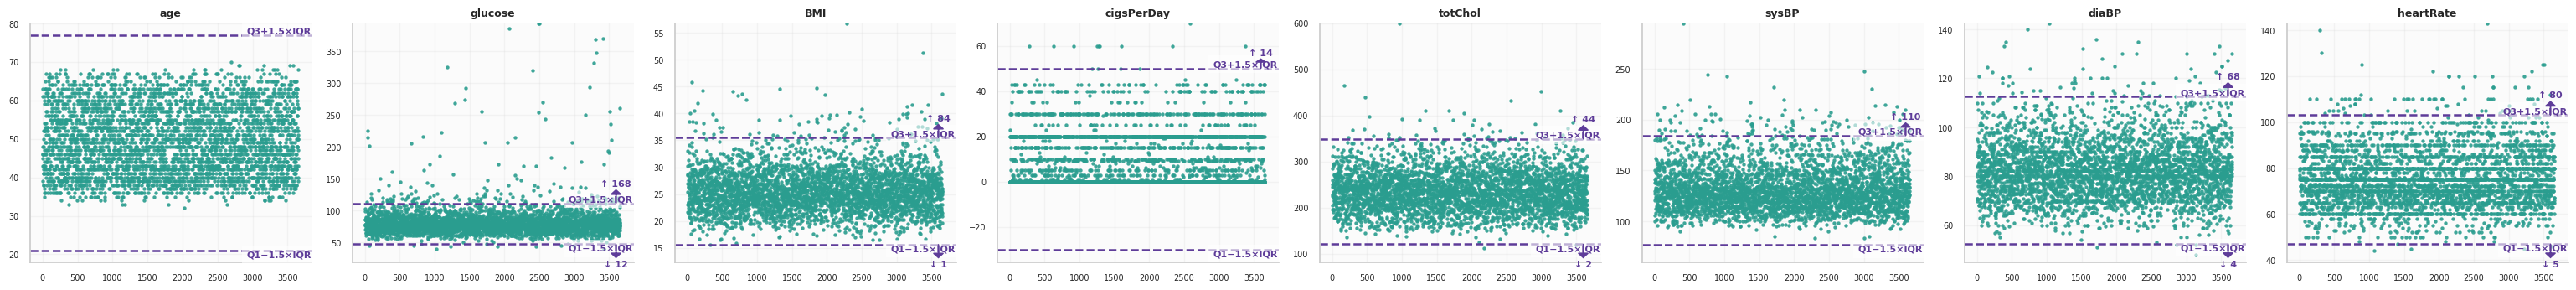

CSV de outliers (Tukey 1.5*IQR) salvo em: ../eda_reports/csv/outliers_iqr_core.csv (linhas: 478)
Linhas removidas do df por regra Tukey 1.5*IQR: 478 (antes=3658, depois=3180)


In [8]:
# [IQR - Tukey 1.5*IQR] Scatter por variável numérica (age, glucose/avg_glucose_level, BMI/bmi)
# - Plota e anota outliers
# - Salva CSV com outliers e flags
# - Atualiza df removendo linhas outliers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import unicodedata

sns.set_theme(style='whitegrid')

# ------------------ Utilidades ------------------
def _normalize_name(name: str) -> str:
    s = unicodedata.normalize('NFKD', str(name))
    s = s.encode('ascii', 'ignore').decode('ascii')
    s = s.lower()
    s = re.sub(r'\(.*?\)', '', s)
    s = re.sub(r'[^a-z0-9]+', '_', s).strip('_')
    return s

# Mapeia variações para nomes-alvo (canônicos)
NAME_ALIASES = {
    'age':        ['age', 'idade'],

    'cigsPerDay': ['cigsPerDay', 'cig_per_day', 'cigs_per_day', 'cigarros_dia', 'cigarrosPorDia'],

    'totChol':    ['totChol', 'total_chol', 'total_cholesterol', 'colesterol_total', 'col_total'],

    'sysBP':      ['sysBP', 'sys_bp', 'systolic_bp', 'systolic', 'pressao_sistolica', 'pa_sistolica'],

    'diaBP':      ['diaBP', 'dia_bp', 'diastolic_bp', 'diastolic', 'pressao_diastolica', 'pa_diastolica'],

    'BMI':        ['BMI', 'bmi', 'imc'],

    'heartRate':  ['heartRate', 'heart_rate', 'hr', 'frequencia_cardiaca', 'freq_cardiaca'],

    # <- esta chave canônica cobre avg_glucose_level e variações
    'glucose':    ['glucose', 'avg_glucose_level', 'avg_glucose', 'glucose_avg',
                   'glicose', 'nivel_glicose', 'glucose_level']
}

def _resolve_columns(df):
    present = {}
    norm_cols = {_normalize_name(c): c for c in df.columns}
    for key, aliases in NAME_ALIASES.items():
        found = None
        for a in aliases:
            na = _normalize_name(a)
            if na in norm_cols:
                found = norm_cols[na]
                break
        present[key] = found
    return present

colmap = _resolve_columns(df)

# Somente colunas existentes
target_cols = {k: v for k, v in colmap.items() if v is not None}

# Série numérica segura
def _to_numeric_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors='coerce')

# ------------------ PLOTS (dinâmico) ------------------
# Use as chaves canônicas corretas (compatíveis com NAME_ALIASES)
ordered_keys = ['age', 'glucose', 'BMI', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'heartRate']
ordered_keys = [k for k in ordered_keys if k in target_cols]

if not ordered_keys:
    raise RuntimeError("Nenhuma de ['age', 'glucose', 'BMI'] foi encontrada no DataFrame.")

# grade dinâmica: 1 linha com N colunas
cols = len(ordered_keys)
rows = 1
fig, axes = plt.subplots(rows, cols, figsize=(3.6*cols + 0.3*(cols-1), 3.6), constrained_layout=False)
axes = np.atleast_1d(axes).flatten()
fig.patch.set_facecolor('white')

point_color = '#2a9d8f'   # teal
tukey_color = '#5e3c99'   # roxo escuro

for i, key in enumerate(ordered_keys):
    c = target_cols[key]
    ax = axes[i]
    ax.set_facecolor('#fbfbfb')

    s = _to_numeric_series(df[c])
    idx = np.arange(len(s))
    ax.scatter(idx, s, s=10, c=point_color, alpha=0.9, linewidths=0)

    s_non = s.dropna()
    if len(s_non) >= 2:
        q1 = float(np.nanpercentile(s_non, 25))
        q3 = float(np.nanpercentile(s_non, 75))
        iqr = q3 - q1
        low_t = q1 - 1.5 * iqr
        high_t = q3 + 1.5 * iqr

        ax.axhline(low_t,  color=tukey_color, linestyle='--', linewidth=1.8, alpha=1.0, zorder=2)
        ax.axhline(high_t, color=tukey_color, linestyle='--', linewidth=1.8, alpha=1.0, zorder=2)

        n_below = int((s <= low_t).sum())
        n_above = int((s >= high_t).sum())

        y_min_data = float(np.nanmin(s_non))
        y_max_data = float(np.nanmax(s_non))
        y_rng = max(1e-9, y_max_data - y_min_data)
        y_low_plot = min(y_min_data, low_t - 0.08 * y_rng)
        y_high_plot = max(y_max_data, high_t + 0.08 * y_rng)
        ax.set_ylim(y_low_plot, y_high_plot)

        x0, x1 = ax.get_xlim()
        ax.text(x1, high_t, 'Q3+1.5×IQR', fontsize=8, color=tukey_color, weight='bold',
                va='bottom', ha='right', bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))
        ax.text(x1, low_t,  'Q1−1.5×IQR', fontsize=8, color=tukey_color, weight='bold',
                va='top', ha='right', bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))

        x_arrow = x1 - 0.06 * (x1 - x0)
        if n_above > 0:
            dy = 0.06 * y_rng
            ax.arrow(x_arrow, high_t, 0, dy, length_includes_head=True,
                     head_width=0.035 * (x1 - x0), head_length=0.02 * y_rng,
                     fc=tukey_color, ec=tukey_color, linewidth=1.0, zorder=3)
            ax.text(x_arrow, high_t + dy + 0.01 * y_rng, f"↑ {n_above}",
                    fontsize=8, color=tukey_color, weight='bold', va='bottom', ha='center')
        if n_below > 0:
            dy = -0.06 * y_rng
            ax.arrow(x_arrow, low_t, 0, dy, length_includes_head=True,
                     head_width=0.035 * (x1 - x0), head_length=0.02 * y_rng,
                     fc=tukey_color, ec=tukey_color, linewidth=1.0, zorder=3)
            ax.text(x_arrow, low_t + dy - 0.01 * y_rng, f"↓ {n_below}",
                    fontsize=8, color=tukey_color, weight='bold', va='top', ha='center')

    ax.set_title(str(c), fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(axis='both', which='major', linestyle='-', alpha=0.18)
    ax.grid(axis='both', which='minor', linestyle='-', alpha=0.08)
    sns.despine(ax=ax, left=False, right=True, top=True, bottom=False)

plt.tight_layout(pad=1.0, w_pad=0.9, h_pad=0.9)

# Salvar figura
try:
    IMAGES
except NameError:
    IMAGES = os.path.join('eda_reports','images')
os.makedirs(IMAGES, exist_ok=True)
dpi = 300
out_img = os.path.join(IMAGES, 'outliers_scatter_iqr_core.png')
plt.savefig(out_img, dpi=dpi, bbox_inches='tight')
print(f'Figura salva em: {out_img}')
plt.show()

# ------------------ CSV de outliers + atualização do df ------------------
# Calcular máscaras para as colunas alvo presentes
outlier_flags = {}
combined_mask = pd.Series(False, index=df.index)

for key in ordered_keys:
    col = target_cols[key]
    s = pd.to_numeric(df[col], errors='coerce')
    s_non = s.dropna()
    if len(s_non) < 2:
        outlier_flags[key] = pd.Series(False, index=df.index)
        continue
    q1 = float(np.nanpercentile(s_non, 25))
    q3 = float(np.nanpercentile(s_non, 75))
    iqr = q3 - q1
    thr_low = q1 - 1.5 * iqr
    thr_high = q3 + 1.5 * iqr
    mask = (s <= thr_low) | (s >= thr_high)
    outlier_flags[key] = mask.fillna(False)
    combined_mask = combined_mask | outlier_flags[key]

# DataFrame de flags
flags_df = pd.DataFrame({f'out_{k}': v.astype(int) for k, v in outlier_flags.items()}, index=df.index)
flags_df['out_any'] = (flags_df.filter(like='out_').sum(axis=1) > 0).astype(int)
def _join_triggers(row):
    cols = [k.replace('out_', '') for k, v in row.items() if k.startswith('out_') and v == 1]
    return ','.join(cols)
flags_df['trigger_cols'] = flags_df.apply(_join_triggers, axis=1)

# Salvar CSV com outliers
try:
    CSV_DIR
except NameError:
    CSV_DIR = os.path.join('eda_reports','csv')
os.makedirs(CSV_DIR, exist_ok=True)

if combined_mask.any():
    out_df = df.loc[combined_mask].copy().join(flags_df.loc[combined_mask])
    csv_path = os.path.join(CSV_DIR, 'outliers_iqr_core.csv')
    out_df.to_csv(csv_path, index=True)
    print(f'CSV de outliers (Tukey 1.5*IQR) salvo em: {csv_path} (linhas: {len(out_df)})')
else:
    print('Nenhum outlier (Tukey 1.5*IQR) encontrado em age/glucose/BMI.')

# Remover do df
if combined_mask.any():
    before = len(df)
    df = df.loc[~combined_mask].copy()
    after = len(df)
    print(f'Linhas removidas do df por regra Tukey 1.5*IQR: {before - after} (antes={before}, depois={after})')
else:
    print('df não alterado: nenhuma linha removida pela regra Tukey 1.5*IQR.')


In [9]:
# Salva versão 'processed' simples para consumo posterior (parquet se possível)
processed_dir = os.path.join('..','data','processed')
os.makedirs(processed_dir, exist_ok=True)
proc_csv = os.path.join(processed_dir, os.path.basename(csv_path))
df.to_csv(os.path.join(processed_dir, 'fhs_framingham.csv'), index=False)
print('Saved processed CSV:', os.path.join(processed_dir, 'fhs_framingham.csv'))


Saved processed CSV: ../data/processed/fhs_framingham.csv


In [10]:
def save_fig(fig, name, dpi=None):
    if dpi is None:
        dpi = OUTPUT_DPI
    path = os.path.join(IMAGES, name)
    fig.savefig(path, bbox_inches='tight', dpi=dpi)
    print(f'Saved {path} (dpi={dpi})')
    return path

# Histogramas em grid - somente colunas numéricas (robusto)
n = len(num_cols)
if n == 0:
    print('Nenhuma coluna numérica detectada - pulando histogramas e boxplots')
else:
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*3.5), constrained_layout=False)
    axes = np.array(axes).flatten()
    last_i = -1
    for i, c in enumerate(num_cols):
        ax = axes[i]
        ser = pd.to_numeric(df[c], errors='coerce').dropna()
        if ser.empty:
            ax.axis('off')
            ax.text(0.5, 0.5, 'no non-NA numeric values', ha='center', va='center')
            ax.set_title(c, fontsize=10)
            last_i = i
            continue
        sns.histplot(ser, ax=ax, kde=True, color='C0')
        ax.set_title(c, fontsize=10)
        last_i = i
    # limpa e esconde eixos extras
    for j in range(last_i+1, len(axes)):
        try:
            axes[j].axis('off')
        except Exception:
            pass
    fig.subplots_adjust(hspace=0.5, wspace=0.4)
    save_fig(fig, 'histograms_grid.png')
    plt.close(fig)

    # Boxplots em grid (robusto) - evita chamar seaborn com dados inválidos
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*3.5), constrained_layout=False)
    axes = np.array(axes).flatten()
    last_i = -1
    for i, c in enumerate(num_cols):
        ax = axes[i]
        ser = pd.to_numeric(df[c], errors='coerce').dropna()
        if ser.empty or ser.nunique() <= 1:
            ax.axis('off')
            ax.text(0.5, 0.5, 'no data or constant', ha='center', va='center')
            ax.set_title(c, fontsize=10)
            last_i = i
            continue
        try:
            sns.boxplot(x=ser, ax=ax, color='C1')
        except Exception:
            ax.axis('off')
            ax.text(0.5, 0.5, 'plot error', ha='center', va='center')
        ax.set_title(c, fontsize=10)
        last_i = i
    for j in range(last_i+1, len(axes)):
        try:
            axes[j].axis('off')
        except Exception:
            pass
    fig.subplots_adjust(hspace=0.6, wspace=0.4)
    save_fig(fig, 'boxplots_grid.png')
    plt.close(fig)

Saved ../eda_reports/images/histograms_grid.png (dpi=800)
Saved ../eda_reports/images/boxplots_grid.png (dpi=800)


In [11]:
# Correlação de Pearson e heatmap anotado apenas para |r| > 0.3 (landscape / horizontal page)
# --- Colunas numéricas para o heatmap (todas exceto EXCLUDE_COLUMNS) ---
_exclude = set(globals().get('EXCLUDE_COLUMNS', []))
num_all = df.select_dtypes(include=[np.number]).columns.tolist()
num_for_corr = [c for c in num_all if c not in _exclude]

# remove colunas constantes (variância zero) para evitar NaNs na correlação
const_cols = [c for c in num_for_corr if df[c].nunique(dropna=True) <= 1]
num_for_corr = [c for c in num_for_corr if c not in const_cols]

# matriz de correlação (Pearson)
corr = df[num_for_corr].corr(method='pearson')
mask = corr.abs() < 0.3
# Preparar anotações: somente onde |r| >= 0.3
annot = corr.round(2).astype(str)
annot = annot.where(~mask, '')
# Use a wider figure for horizontal/landscape layout
fig_w = max(11, len(num_cols) * 0.35)
fig_h = max(6, len(num_cols) * 0.2)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    corr,
    mask=None,
    cmap='coolwarm',
    center=0,
    ax=ax,
    annot=annot,
    fmt='',
    annot_kws={'size':5, 'weight':'bold'},
    linewidths=0.2,
    square=False,
    cbar_kws={'shrink':1.0}
)
# reduce tick label sizes
ax.tick_params(axis='both', which='major', labelsize=7)
ax.set_title('Pearson Correlation (only |r| >= 0.3 annotated)', fontsize=12)
plt.tight_layout()
# save as a landscape PNG using OUTPUT_DPI
save_fig(fig, 'correlation_heatmap.png', dpi=OUTPUT_DPI)
plt.close(fig)


Saved ../eda_reports/images/correlation_heatmap.png (dpi=800)


In [12]:
# Normality tests (Shapiro / D'Agostino) for top skewed numeric variables - Q-Q plots removed as requested
from scipy.stats import shapiro, normaltest
# Compute skewness and pick top skewed numeric columns (stable against non-numeric)
skew_vals = df[num_cols].apply(lambda x: pd.to_numeric(x, errors='coerce').dropna().skew())
skewed = skew_vals.abs().sort_values(ascending=False).head(6).index.tolist()
print('Top skewed cols (for tests):', skewed)
results = []
for c in skewed:
    # Coerce to numeric and drop NA
    series = pd.to_numeric(df[c], errors='coerce').dropna()
    n = len(series)
    info = {'variable': c, 'n': n, 'shapiro_stat': None, 'shapiro_p': None, 'dagostino_stat': None, 'dagostino_p': None, 'notes': ''}
    if n == 0:
        info['notes'] = 'no_non_na_values'
        results.append(info)
        continue
    # skip constant columns (variance==0) which break tests
    if series.nunique() <= 1 or series.std() == 0 or series.var() == 0:
        info['notes'] = 'constant_or_zero_variance'
        results.append(info)
        continue
    # sample for large n to keep Shapiro runtime reasonable
    sample = series.sample(n=min(n, 5000), random_state=0) if n > 5000 else series
    # Shapiro: recommended for n <= 5000; wrap in try/except
    try:
        s_stat, s_p = shapiro(sample)
        info['shapiro_stat'] = float(s_stat) if s_stat is not None else None
        info['shapiro_p'] = float(s_p) if s_p is not None else None
    except Exception as e:
        info['notes'] += ' shapiro_failed:' + str(e)
    # D'Agostino (normaltest) requires at least 8 samples
    try:
        if len(sample) >= 8:
            n_stat, n_p = normaltest(sample)
            info['dagostino_stat'] = float(n_stat)
            info['dagostino_p'] = float(n_p)
        else:
            info['notes'] += ' dagostino_skipped_small_n'
    except Exception as e:
        info['notes'] += ' dagostino_failed:' + str(e)
    results.append(info)
# Results dataframe with richer diagnostics
results_df = pd.DataFrame(results).set_index('variable')
display(results_df)
results_df.to_csv(os.path.join(CSV_DIR, 'normality_tests.csv'))

Top skewed cols (for tests): ['cigsPerDay', 'sysBP', 'glucose', 'age', 'BMI', 'totChol']


,n,shapiro_stat,shapiro_p,dagostino_stat,dagostino_p,notes
variable,,,,,,
cigsPerDay,3180,0.768775,3.501296e-55,417.212643,2.531778e-91,
sysBP,3180,0.972467,2.756548e-24,167.905470,3.465695e-37,
glucose,3180,0.986146,4.236959e-17,78.217110,1.036026e-17,
age,3180,0.965170,4.663211e-27,535.131016,6.277350e-117,
BMI,3180,0.993262,5.220268e-11,44.383176,2.303116e-10,
totChol,3180,0.993227,4.767024e-11,44.270121,2.437055e-10,


In [13]:
# VIF calculation for numeric variables (drop rows with NA for VIF calculation)
try:
    import statsmodels.api as sm
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X = df[num_cols].select_dtypes(include=[float, int]).dropna()
    if X.shape[0] > 0 and X.shape[1] > 0:
        vif_vals = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        vif = pd.Series(vif_vals, index=X.columns).sort_values(ascending=False)
        display(vif)
        vif.to_csv(os.path.join(CSV_DIR, 'vif_values.csv'))
    else:
        print('Insufficient data for VIF calculation (need non-NA rows)')
except Exception as e:
    print('VIF calculation failed (statsmodels required):', e)

diaBP         154.877829
sysBP         145.487775
BMI            56.634953
heartRate      45.035402
glucose        42.656801
age            42.140056
totChol        37.786346
cigsPerDay      1.641607
dtype: float64

In [14]:
# Pairplot for a sampled subset of numeric variables (by variance) to avoid explosion
try:
    # ensure numeric cols list excludes any id/diagnosis-like columns as an extra guard
    excluded = set([c.lower() for c in df.columns if c.lower() in ('id','patient_id','patientid','record_id','serial_number','diagnosis','diagnose','diagnóstico','target','label','class','y')])
    safe_num_cols = [c for c in num_cols if c.lower() not in excluded]
    var = df[safe_num_cols].var().sort_values(ascending=False)
    top_cols = var.head(6).index.tolist()
    sample = df[top_cols].dropna().sample(n=min(300, len(df)), random_state=0)
    pp = sns.pairplot(sample, height=1.5)
    pp.fig.suptitle('Pairplot - top variance numeric cols', y=1.02)
    pp.fig.tight_layout()
    pp.fig.savefig(os.path.join(IMAGES, 'pairplot_top_variance.png'))
    plt.close('all')
except Exception as e:
    print('Pairplot failed (possibly too many/missing values):', e)

## Próximos passos
- Verificar se as colunas categóricas precisam ser tratadas (label-encoding) antes de modelagem.
- Adicionar análise de missingness visual (matrix/heatmap) se dataset tiver valores ausentes.
- Versionar `data/processed` com timestamp ou hash do raw.